# 🧠 OnePilot — Forecasting | Notebook 4 : LSTM
**Modèle** : LSTM Vanilla 2 couches (PyTorch)  
**Données** : `/tmp/northwind_weekly_train.csv` (hebdo — 79 pts)  
**Output** : MAE + prévisions sauvegardées pour l'Ensemble (Notebook 5)

In [1]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import warnings; warnings.filterwarnings('ignore')

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

plt.rcParams.update({
    'figure.facecolor': '#060a0e', 'axes.facecolor': '#0d1520',
    'axes.edgecolor': '#182336',   'text.color': '#d8e8f2',
    'axes.labelcolor': '#7ea4be',  'xtick.color': '#7ea4be',
    'ytick.color': '#7ea4be',      'grid.color': '#182336',
    'grid.linestyle': '--',        'grid.alpha': 0.5
})
print(f'✅ Imports OK')
print(f'   Device : {device}')
print(f'   PyTorch: {torch.__version__}')

✅ Imports OK
   Device : cpu
   PyTorch: 2.11.0+cu130


In [2]:
# ── Chargement données hebdomadaires ─────────────────────────────
train_w = pd.read_csv('/tmp/northwind_weekly_train.csv', index_col='date', parse_dates=True)
test_w  = pd.read_csv('/tmp/northwind_weekly_test.csv',  index_col='date', parse_dates=True)
full_w  = pd.read_csv('/tmp/northwind_weekly.csv',       index_col='date', parse_dates=True)

train_series = train_w['revenu'].astype(float).values
test_series  = test_w['revenu'].astype(float).values
full_series  = full_w['revenu'].astype(float).values

print(f'✅ Données hebdomadaires chargées')
print(f'   Train : {len(train_series)} semaines')
print(f'   Test  : {len(test_series)} semaines')
print(f'   Total : {len(full_series)} semaines')
print(f'   Revenu moyen train : {train_series.mean():,.0f} €')

✅ Données hebdomadaires chargées
   Train : 79 semaines
   Test  : 20 semaines
   Total : 99 semaines
   Revenu moyen train : 10,285 €


In [3]:
# ── Normalisation MinMaxScaler ────────────────────────────────────
# LSTM apprend mieux sur des valeurs entre 0 et 1
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_series.reshape(-1, 1)).flatten()
full_scaled  = scaler.transform(full_series.reshape(-1, 1)).flatten()

# ── Sliding window ───────────────────────────────────────────────
# WINDOW = nombre de semaines passées utilisées pour prédire la suivante
WINDOW = 8  # 8 semaines (~2 mois) → prédire la semaine suivante

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW)

# Convertir en tenseurs PyTorch
X_t = torch.FloatTensor(X_train).unsqueeze(-1).to(device)  # [N, window, 1]
y_t = torch.FloatTensor(y_train).to(device)

print(f'✅ Sliding window créée')
print(f'   Window size : {WINDOW} semaines')
print(f'   Séquences   : {X_t.shape[0]} (train)')
print(f'   Shape X     : {X_t.shape}  [N, window, features]')

✅ Sliding window créée
   Window size : 8 semaines
   Séquences   : 71 (train)
   Shape X     : torch.Size([71, 8, 1])  [N, window, features]


In [4]:
# ── Architecture LSTM Vanilla 2 couches ──────────────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

# ── Entraînement ──────────────────────────────────────────────────
HIDDEN   = 64
LAYERS   = 2
EPOCHS   = 100
LR       = 0.001
BATCH    = 16

model_lstm = LSTMForecaster(hidden_size=HIDDEN, num_layers=LAYERS).to(device)
optimizer  = torch.optim.Adam(model_lstm.parameters(), lr=LR)
criterion  = nn.MSELoss()
dataset    = TensorDataset(X_t, y_t)
loader     = DataLoader(dataset, batch_size=BATCH, shuffle=True)

print(f'🧠 Entraînement LSTM ({EPOCHS} epochs, device={device})...')
losses = []
for epoch in range(EPOCHS):
    model_lstm.train()
    epoch_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model_lstm(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(loader))
    if (epoch+1) % 20 == 0:
        print(f'   Epoch {epoch+1:3d}/{EPOCHS} — Loss: {losses[-1]:.6f}')

print(f'✅ Entraînement terminé — Loss finale: {losses[-1]:.6f}')

🧠 Entraînement LSTM (100 epochs, device=cpu)...
   Epoch  20/100 — Loss: 0.031439
   Epoch  40/100 — Loss: 0.031532
   Epoch  60/100 — Loss: 0.031722
   Epoch  80/100 — Loss: 0.028346
   Epoch 100/100 — Loss: 0.028830
✅ Entraînement terminé — Loss finale: 0.028830


In [5]:
# ── Prévision récursive ───────────────────────────────────────────
# On prédit semaine par semaine en utilisant les prédictions précédentes
n_test    = len(test_series)
n_horizon = 12   # 12 semaines supplémentaires (~3 mois)
n_total   = n_test + n_horizon

model_lstm.eval()
preds_scaled = []

# Fenêtre initiale = dernières WINDOW semaines du train
window = list(train_scaled[-WINDOW:])

with torch.no_grad():
    for _ in range(n_total):
        x_in = torch.FloatTensor(window[-WINDOW:]).unsqueeze(0).unsqueeze(-1).to(device)
        pred = model_lstm(x_in).item()
        preds_scaled.append(pred)
        window.append(pred)

# Dénormalisation
preds_scaled_arr = np.array(preds_scaled).reshape(-1, 1)
preds_scaled_arr = np.clip(preds_scaled_arr, 0, 1)  # clip avant inverse_transform
forecast_vals = scaler.inverse_transform(preds_scaled_arr).flatten()
forecast_vals = np.clip(forecast_vals, 0, None)

# Index de dates
last_train_date = train_w.index[-1]
future_index = pd.date_range(start=last_train_date + pd.Timedelta(weeks=1),
                              periods=n_total, freq='W')

df_forecast_lstm = pd.DataFrame({
    'forecast': forecast_vals
}, index=future_index)

print(f'✅ Prévisions générées ({n_total} semaines)')
print(df_forecast_lstm.head(8).round(0).to_string())

✅ Prévisions générées (32 semaines)
            forecast
1998-01-04   11869.0
1998-01-11   11978.0
1998-01-18   12073.0
1998-01-25   11957.0
1998-02-01   11906.0
1998-02-08   11783.0
1998-02-15   11744.0
1998-02-22   11575.0


In [6]:
# ── IC 95% via Monte Carlo Dropout ───────────────────────────────
# On active le dropout pendant l'inférence → 50 passages → std = IC
def predict_mc(model, window_init, n_steps, n_samples=50):
    model.train()  # active le dropout
    all_preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            window = list(window_init)
            preds = []
            for _ in range(n_steps):
                x_in = torch.FloatTensor(window[-WINDOW:]).unsqueeze(0).unsqueeze(-1).to(device)
                pred = model(x_in).item()
                preds.append(pred)
                window.append(pred)
            all_preds.append(preds)
    model.eval()
    arr = np.array(all_preds)  # [n_samples, n_steps]
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    return mean, mean - 1.96*std, mean + 1.96*std

mean_s, lower_s, upper_s = predict_mc(model_lstm, train_scaled[-WINDOW:], n_total)

# Dénormalisation des IC
lower_vals = scaler.inverse_transform(np.clip(lower_s, 0, 1).reshape(-1,1)).flatten()
upper_vals = scaler.inverse_transform(np.clip(upper_s, 0, 1).reshape(-1,1)).flatten()
lower_vals = np.clip(lower_vals, 0, None)

df_forecast_lstm['lower_95'] = lower_vals
df_forecast_lstm['upper_95'] = upper_vals

print('✅ IC 95% calculés via Monte Carlo Dropout (50 passages)')

✅ IC 95% calculés via Monte Carlo Dropout (50 passages)


In [7]:
# ── MAE sur période de test ───────────────────────────────────────
# Aligner les prévisions hebdo avec les vraies valeurs de test
forecast_test = df_forecast_lstm['forecast'].iloc[:n_test].values
mae  = mean_absolute_error(test_series, forecast_test)
mape = np.mean(np.abs((test_series - forecast_test) / (test_series + 1e-8))) * 100

print('='*45)
print('  PERFORMANCE LSTM')
print('='*45)
print(f'  MAE  : {mae:,.0f} €')
print(f'  MAPE : {mape:.1f} %')
print(f'  Horizon évalué : {n_test} semaines')

# Comparaison avec SARIMA et Prophet
try:
    s_mae = float(pd.read_csv('/tmp/sarima_metrics.csv',  index_col=0, header=None).loc['mae', 1])
    p_mae = float(pd.read_csv('/tmp/prophet_metrics.csv', index_col=0, header=None).loc['mae', 1])
    print(f'\n  Comparaison (hebdo vs mensuel — indicatif) :')
    print(f'  SARIMA  MAE : {s_mae:,.0f} €')
    print(f'  Prophet MAE : {p_mae:,.0f} €')
    print(f'  LSTM    MAE : {mae:,.0f} €')
    best = min([(s_mae,'SARIMA'),(p_mae,'Prophet'),(mae,'LSTM')], key=lambda x: x[0])
    print(f'  Meilleur individuel : {best[1]} ✅')
except: pass

  PERFORMANCE LSTM
  MAE  : 11,890 €
  MAPE : 50.4 %
  Horizon évalué : 20 semaines

  Comparaison (hebdo vs mensuel — indicatif) :
  SARIMA  MAE : 40,390 €
  Prophet MAE : 42,399 €
  LSTM    MAE : 11,890 €
  Meilleur individuel : LSTM ✅


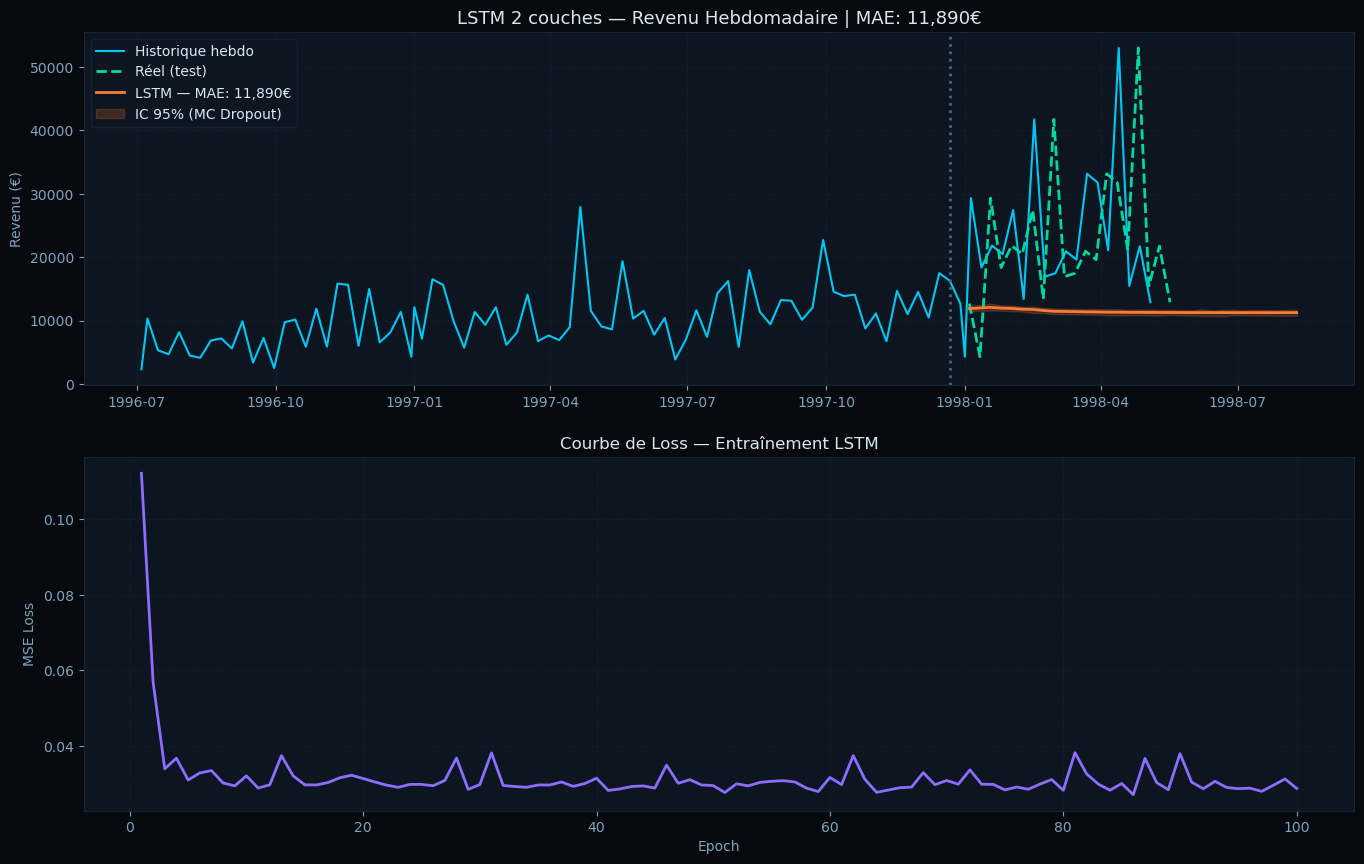

✅ Graphique sauvegardé → /tmp/lstm_forecast.png


In [8]:
# ── Visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Graphique 1 — Prévision
ax1 = axes[0]
ax1.plot(full_w.index, full_series, color='#00c8f5', lw=1.5, label='Historique hebdo')
ax1.plot(df_forecast_lstm.index[:n_test], test_series,
         color='#00d9a0', lw=2, linestyle='--', label='Réel (test)')
ax1.plot(df_forecast_lstm.index, df_forecast_lstm['forecast'],
         color='#ff7a35', lw=2, label=f'LSTM — MAE: {mae:,.0f}€')
ax1.fill_between(df_forecast_lstm.index,
                 df_forecast_lstm['lower_95'], df_forecast_lstm['upper_95'],
                 alpha=0.2, color='#ff7a35', label='IC 95% (MC Dropout)')
ax1.axvline(x=train_w.index[-1], color='#45657e', linestyle=':', lw=2)
ax1.set_title(f'LSTM 2 couches — Revenu Hebdomadaire | MAE: {mae:,.0f}€',
              color='#d8e8f2', fontsize=13)
ax1.set_ylabel('Revenu (€)', color='#7ea4be')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.legend(facecolor='#0d1520', edgecolor='#182336', labelcolor='#d8e8f2')
ax1.grid(True)

# Graphique 2 — Courbe de loss
ax2 = axes[1]
ax2.plot(range(1, EPOCHS+1), losses, color='#8b6eff', lw=2)
ax2.set_title('Courbe de Loss — Entraînement LSTM', color='#d8e8f2', fontsize=12)
ax2.set_xlabel('Epoch', color='#7ea4be')
ax2.set_ylabel('MSE Loss', color='#7ea4be')
ax2.grid(True)

plt.tight_layout(pad=2)
plt.savefig('/tmp/lstm_forecast.png', dpi=120, bbox_inches='tight', facecolor='#060a0e')
plt.show()
print('✅ Graphique sauvegardé → /tmp/lstm_forecast.png')

In [9]:
# ── Sauvegarde pour Notebook 5 (Ensemble) ────────────────────────
df_forecast_lstm.to_csv('/tmp/lstm_forecast.csv')
pd.Series({'mae': mae, 'mape': mape, 'model': 'LSTM'}).to_csv('/tmp/lstm_metrics.csv')
torch.save(model_lstm.state_dict(), '/tmp/lstm_model.pt')

print('✅ Résultats sauvegardés :')
print('   /tmp/lstm_forecast.csv  → prévisions + IC 95%')
print('   /tmp/lstm_metrics.csv   → MAE, MAPE')
print('   /tmp/lstm_model.pt      → poids du modèle')
print()
print(f'📊 Résumé LSTM :')
print(f'   Architecture : 2 couches × {HIDDEN} unités hidden')
print(f'   Window       : {WINDOW} semaines')
print(f'   Epochs       : {EPOCHS}')
print(f'   MAE          : {mae:,.0f} €')
print(f'   MAPE         : {mape:.1f} %')
print()
print('→ Prochain notebook : Notebook 5 — Ensemble')

✅ Résultats sauvegardés :
   /tmp/lstm_forecast.csv  → prévisions + IC 95%
   /tmp/lstm_metrics.csv   → MAE, MAPE
   /tmp/lstm_model.pt      → poids du modèle

📊 Résumé LSTM :
   Architecture : 2 couches × 64 unités hidden
   Window       : 8 semaines
   Epochs       : 100
   MAE          : 11,890 €
   MAPE         : 50.4 %

→ Prochain notebook : Notebook 5 — Ensemble
